In [21]:
import pandas as pd
import os

# Read and clean cloud seeding operation data
os.chdir('/Users/anora/Team MG Dropbox/Wanru Wu/Cloudseeding_Anora/新炮台数据')
seeding = pd.read_excel('DM_2022-2023.xlsx')
seeding = seeding.dropna(how='all', axis=1)

seeding['作业日期'] = pd.to_datetime(seeding['作业日期'])
seeding['year'] = seeding['作业日期'].dt.year
seeding['month'] = seeding['作业日期'].dt.month
seeding['day'] = seeding['作业日期'].dt.day

seeding = seeding.drop(columns=['序号','作业日期'])

seeding

,站点编号,作业开始时间,作业结束时间,作业装备,催化剂及用量,作业目的,服务领域,作业前天气状况,作业前天气状况.1,作业面积,作业效果,year,month,day
0,361002003,23:24:00,23:25:00,71020399,7110201002,增雨,改善空气,阴,小雨,150,50.0,2023,12,30
1,360322005,17:30:00,17:31:00,71020399,7110201001,增雨,农业抗旱,阴,阴,150,50.0,2023,12,30
2,361126006,10:02:00,10:03:00,71020399,7110201002,增雨,改善空气,阴,小雨,150,50.0,2023,12,30
3,360902015,09:57:00,10:02:00,71030699,7110508002,增雨,改善空气,阴,阴,50,25.0,2023,12,30
4,360112004,09:10:00,09:40:00,71030699,7110508002,增雨,农业抗旱,阴,小雨,75,25.0,2023,12,30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4001,360124003,08:55:00,08:56:00,71020199,7110201002,增雨,农业抗旱,阴,小雨,50,150.0,2022,1,5
4002,360902015,07:30:00,07:45:00,71030699,7110508001,增雨,改善空气,阴,小雨,100,50.0,2022,1,5
4003,360112004,07:01:00,07:32:00,71030699,7130510002,增雨,农业抗旱,小雨,小到中雨,15,15.0,2022,1,5
4004,360123011,06:36:00,07:06:00,71030499,7130510002,增雨,农业抗旱,阵雨,小到中雨,110,65.0,2022,1,5


In [22]:
seeding['作业装备'].unique()

array([71020399, 71030699, 71030499, 71020299, 71020199])

In [15]:

from pyhdf.SD import SD, SDC

path = "/Users/anora/Team MG Dropbox/Wanru Wu/Cloudseeding/Cloud Seeding/data/modis_level2/2022/001/MYD06_L2.A2022001.0000.061.2022003185515.hdf"
hdf = SD(path, SDC.READ)

# List all variables
datasets = hdf.datasets()



In [16]:
arrays = {}
for name in datasets.keys():
    try:
        arr = hdf.select(name)[:]
        arrays[name] = arr
    except Exception as e:
        print(f"Skip {name}: {e}")

In [18]:
import numpy as np
for k,v in arrays.items():
    print(k, np.shape(v))

Latitude (406, 270)
Longitude (406, 270)
Scan_Start_Time (406, 270)
Solar_Zenith (406, 270)
Solar_Zenith_Day (406, 270)
Solar_Zenith_Night (406, 270)
Solar_Azimuth (406, 270)
Solar_Azimuth_Day (406, 270)
Solar_Azimuth_Night (406, 270)
Sensor_Zenith (406, 270)
Sensor_Zenith_Day (406, 270)
Sensor_Zenith_Night (406, 270)
Sensor_Azimuth (406, 270)
Sensor_Azimuth_Day (406, 270)
Sensor_Azimuth_Night (406, 270)
Brightness_Temperature (7, 406, 270)
Surface_Temperature (406, 270)
Surface_Pressure (406, 270)
Cloud_Height_Method (406, 270)
Cloud_Top_Height (406, 270)
Cloud_Top_Height_Nadir (406, 270)
Cloud_Top_Height_Nadir_Day (406, 270)
Cloud_Top_Height_Nadir_Night (406, 270)
Cloud_Top_Pressure (406, 270)
Cloud_Top_Pressure_Nadir (406, 270)
Cloud_Top_Pressure_Night (406, 270)
Cloud_Top_Pressure_Nadir_Night (406, 270)
Cloud_Top_Pressure_Day (406, 270)
Cloud_Top_Pressure_Nadir_Day (406, 270)
Cloud_Top_Temperature (406, 270)
Cloud_Top_Temperature_Nadir (406, 270)
Cloud_Top_Temperature_Night (406, 2

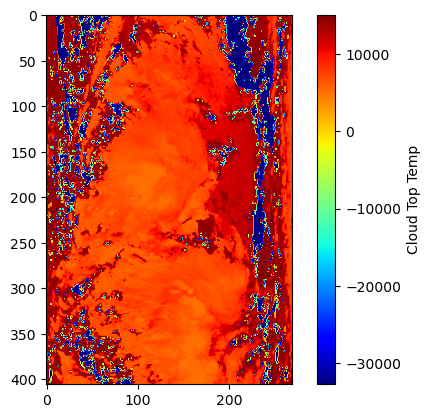

In [19]:
import matplotlib.pyplot as plt
import numpy as np

arr = hdf.select("Cloud_Top_Temperature")[:]
plt.imshow(arr, cmap="jet")
plt.colorbar(label="Cloud Top Temp")
plt.show()